## Training Data for detecting Gear equipement into a text

### Curating & Uploading Data to HuggingFaces

In [11]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
load_dotenv(override=True)

True

In [12]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [13]:
# load dataset from file gear_dataset.jsonl
dataset = load_dataset('json', data_files='gear_dataset.jsonl', split='train')

In [14]:
print("length of dataset:", len(dataset))
dataset[0]

length of dataset: 428


{'route_id': '1899949',
 'gear': 'La voie est pratiquement équipée.\n13 dégaines.\nUn jeu de friend du 0.3 au 2 est nécessaire pour certaines longueurs.',
 'equipment': [{'name': 'Dégaines', 'quantity': 13, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #0.3', 'quantity': 1, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #0.4', 'quantity': 1, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #0.5', 'quantity': 1, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #0.75', 'quantity': 1, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #1', 'quantity': 1, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #1.5', 'quantity': 1, 'notes': 'obligatoire'},
  {'name': 'Friend / coinceur #2', 'quantity': 1, 'notes': 'obligatoire'}]}

In [15]:
from gear_loader import GearLoader

items = []
loader = GearLoader()
items.extend(loader.load(dataset_file='gear_dataset.jsonl'))

100%|██████████| 1/1 [00:00<00:00, 12.58it/s]


Completed gear loading with 428 datapoints in 0.0 mins


In [16]:
random.seed(42)
random.shuffle(items)

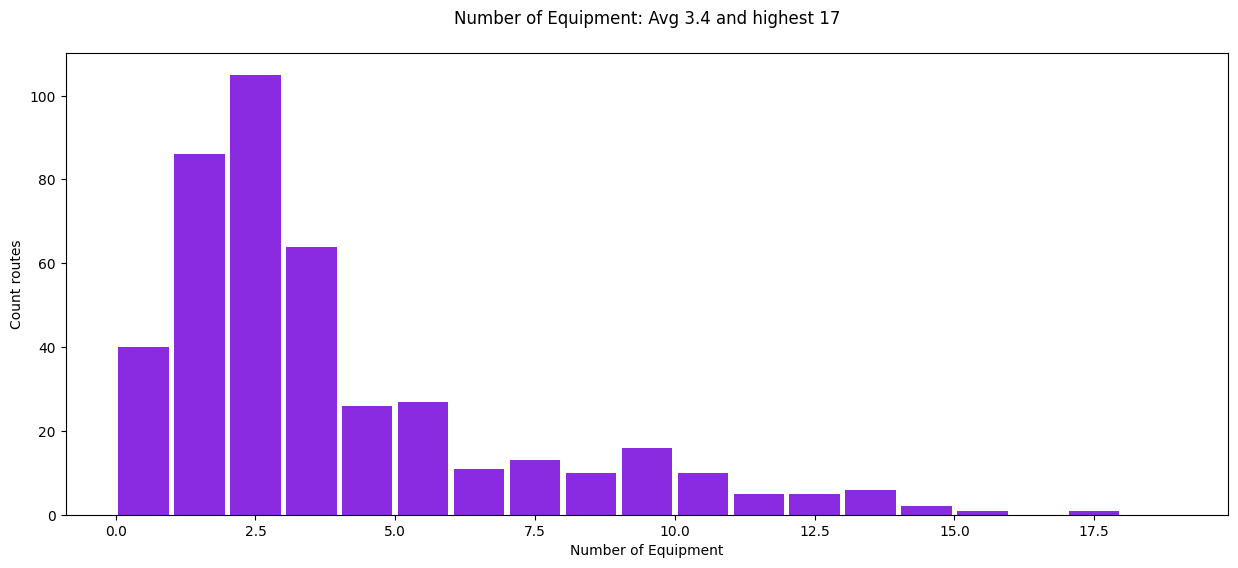

In [17]:
# Plot the distribution of eupment nb
nbEq = [len(item.equipment) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Number of Equipment: Avg {sum(nbEq)/len(nbEq):.1f} and highest {max(nbEq):,}\n")
plt.xlabel('Number of Equipment')
plt.ylabel('Count routes')
plt.hist(nbEq, rwidth=0.9, color="blueviolet", bins=range(0, 20, 1))
plt.show()

### Add Prompt & completion

In [18]:
from equipment import Equipment

for item in items:
    item.make_prompt()

print("PROMPT:")
print(items[0].prompt)

print('------')
print("COMPLETION:")
print(items[0].completion)


PROMPT:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 28 Apr 2026

You are a mountain climbing equipment assistant. Parse the following gear description and return a JSON array. Each element must have exactly three fields:
	- "name": equipment name (string, in french)
	- "quantity": number needed (integer, 1 if unspecified)
	- "notes": "optional" or "mandatory" (translated in french), plus any relevant detail (string, in french)
The name of these equipments are related with the mountain activities. You should only point out personal equipment, for instance quickdraws or rope.
You should include only equipment you're absolutely sure about. Output ONLY the JSON array, no explanation.<|eot_id|><|start_header_id|>user<|end_header_id|>

Gear description:
 - casque
- corde de 30 m, mieux 40 m pour la descente (une vieille sangle montre un autre rappel possible au fond des difficultés, plus sur le versant S, demandant peut-être 

  0%|          | 0/428 [00:00<?, ?it/s]

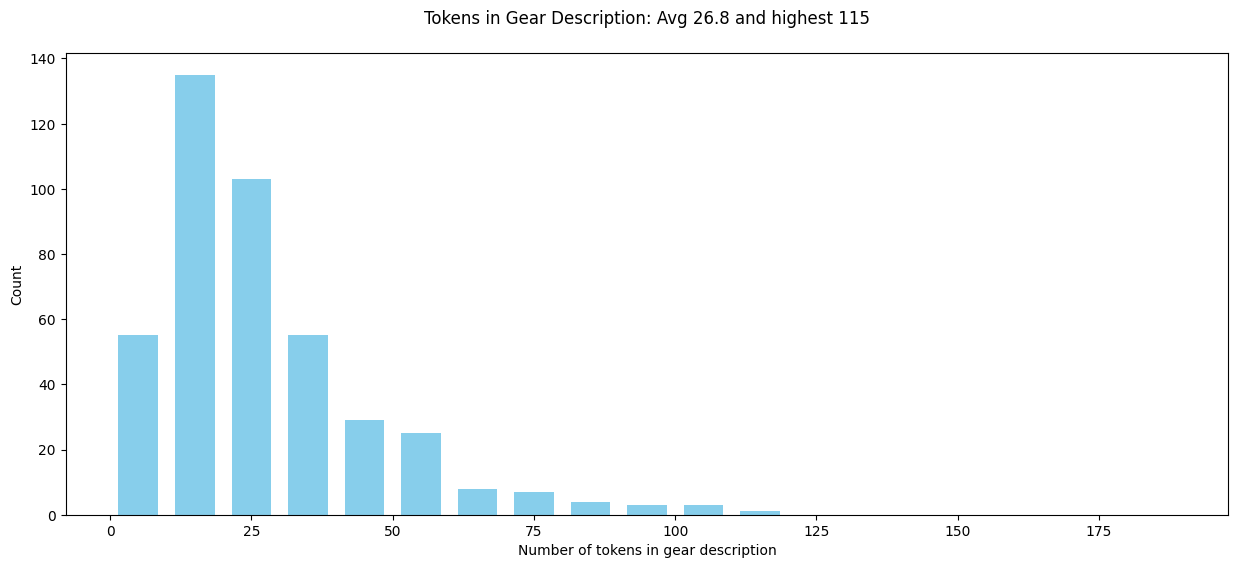

In [19]:
from transformers import AutoTokenizer
BASE_MODEL = "meta-llama/Llama-3.2-3B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Gear Description: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in gear description')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

### Push to Hugging Face

In [10]:
username = "yrichard"
full = f"{username}/gear_raw"

size = len(items)
train = items[:350]
val = items[350:400]
test = items[400:]

Equipment.push_to_hub(full, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/726 [00:00<?, ?B/s]

### Training is done in Google Collab

## Testing